<a href="https://colab.research.google.com/github/evoiresuite/metal-classification-mobilenetv3/blob/main/Metal_Classification_MobileNetV3Small.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1Import Library
import os, json, zipfile, random, time, glob, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from google.colab import files
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_auc_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0 | GPU: []


In [2]:
#2Konfigurasi dan Upload Dataset
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 64
EPOCHS      = 100
LR          = 1e-3
DROPOUT     = 0.3
THRESHOLD   = 0.5          # ambang: prob >= 0.5 dianggap Metal
DATA_DIR    = "/content/dataset"
RESULTS_DIR = "/content/results_metal"
os.makedirs(RESULTS_DIR, exist_ok=True)

if not os.path.isdir(f"{DATA_DIR}/train"):
    up = files.upload()
    ZIP_PATH = list(up.keys())[0]
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)
print(sorted(os.listdir(DATA_DIR)))

Saving material-classification.v2-materals-ai-v1.folder.zip to material-classification.v2-materals-ai-v1.folder.zip
['README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


kelas,Metal,Bukan Metal
split,,
train,6072,22192
valid,832,2196
test,770,2258


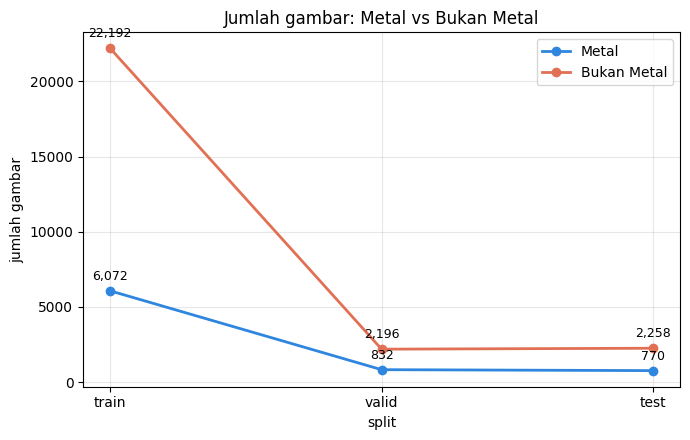

In [3]:
#3Distribusi Data (Metal vs Bukan Metal)
exts = (".jpg", ".jpeg", ".png")
rows = []
for split in ["train", "valid", "test"]:
    for cls in sorted(os.listdir(f"{DATA_DIR}/{split}")):
        p = f"{DATA_DIR}/{split}/{cls}"
        if os.path.isdir(p):
            n = sum(f.lower().endswith(exts) for f in os.listdir(p))
            rows.append((split, "Metal" if cls == "Metal" else "Bukan Metal", n))
dist = pd.DataFrame(rows, columns=["split", "kelas", "n"]).groupby(["split", "kelas"]).n.sum().unstack()
dist = dist.loc[["train", "valid", "test"]][["Metal", "Bukan Metal"]]
display(dist)

plt.figure(figsize=(7, 4.5))
for col, color in zip(dist.columns, ["#2e86de", "#e17055"]):
    plt.plot(dist.index, dist[col], marker="o", linewidth=2, color=color, label=col)
    for x, y in zip(dist.index, dist[col]):
        plt.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.title("Jumlah gambar: Metal vs Bukan Metal")
plt.xlabel("split"); plt.ylabel("jumlah gambar"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/class_distribution.png", dpi=150); plt.show()

Found 28264 files belonging to 6 classes.
Found 3028 files belonging to 6 classes.
Found 3028 files belonging to 6 classes.
['Glass', 'Metal', 'Paper', 'Plastic', 'Unkown', 'Unlabeled'] | index Metal: 1


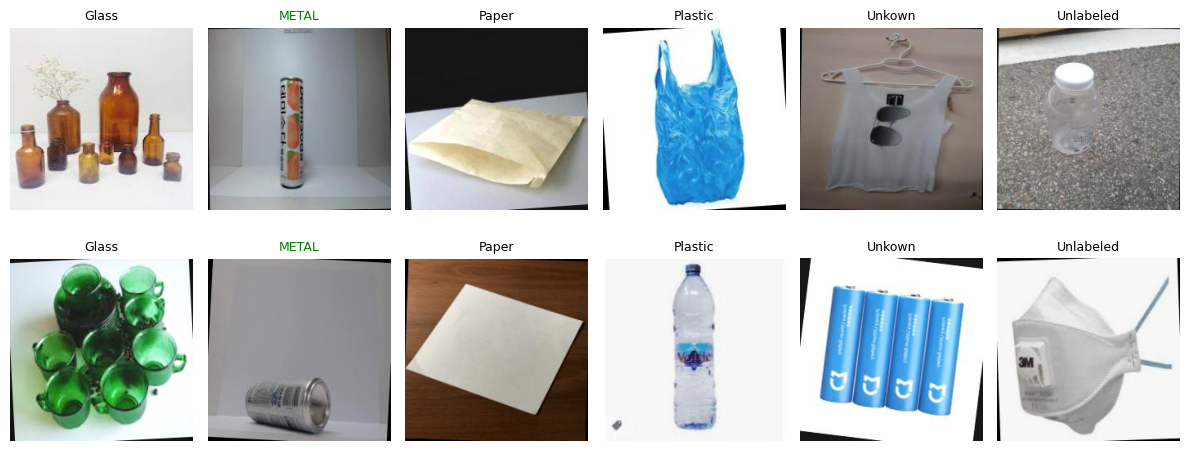

In [4]:
#4Load Dataset dan Contoh Gambar
def load(split):
    return keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/{split}", label_mode="int", image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False, seed=SEED)

train_ds, val_ds, test_ds = load("train"), load("valid"), load("test")
class_names = train_ds.class_names
METAL_IDX = class_names.index("Metal")
BIN_NAMES = ["Bukan Metal", "Metal"]
print(class_names, "| index Metal:", METAL_IDX)

plt.figure(figsize=(12, 5))
for c, name in enumerate(class_names):
    for r, f in enumerate(random.sample(glob.glob(f"{DATA_DIR}/train/{name}/*.jpg"), 2)):
        plt.subplot(2, len(class_names), r * len(class_names) + c + 1)
        plt.imshow(plt.imread(f)); plt.axis("off")
        plt.title("METAL" if name == "Metal" else name, fontsize=9,
                  color="green" if name == "Metal" else "black")
plt.tight_layout(); plt.show()

In [5]:
#5Ekstraksi Fitur (Backbone MobileNetV3-Small Beku)
base = keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet", pooling="avg")
base.trainable = False

def extract(ds):
    feats = base.predict(ds, verbose=1)
    labels = np.concatenate([y.numpy() for _, y in ds])
    return feats, labels

t0 = time.time()
X_train, y6_train = extract(train_ds)
X_val,   y6_val   = extract(val_ds)
X_test,  y6_test  = extract(test_ds)

# label biner: 1 = Metal, 0 = bukan Metal
y_train = (y6_train == METAL_IDX).astype(int)
y_val   = (y6_val   == METAL_IDX).astype(int)
y_test  = (y6_test  == METAL_IDX).astype(int)
print(f"Selesai {time.time()-t0:.0f}s | Metal train/val/test:", y_train.sum(), y_val.sum(), y_test.sum())

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
442/442 ━━━━━━━━━━━━━━━━━━━━ 195s 440ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 446ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step
Selesai 304s | Metal train/val/test: 6072 832 770


Epoch 1/100
111/111 - 1s - 9ms/step - accuracy: 0.7270 - loss: 0.5124 - val_accuracy: 0.8359 - val_loss: 0.3792 - learning_rate: 0.0010
Epoch 2/100
111/111 - 0s - 4ms/step - accuracy: 0.8318 - loss: 0.3604 - val_accuracy: 0.8563 - val_loss: 0.3267 - learning_rate: 0.0010
Epoch 3/100
111/111 - 0s - 3ms/step - accuracy: 0.8473 - loss: 0.3288 - val_accuracy: 0.8705 - val_loss: 0.3012 - learning_rate: 0.0010
Epoch 4/100
111/111 - 0s - 3ms/step - accuracy: 0.8583 - loss: 0.3084 - val_accuracy: 0.8752 - val_loss: 0.2933 - learning_rate: 0.0010
Epoch 5/100
111/111 - 0s - 3ms/step - accuracy: 0.8628 - loss: 0.3007 - val_accuracy: 0.8804 - val_loss: 0.2861 - learning_rate: 0.0010
Epoch 6/100
111/111 - 0s - 3ms/step - accuracy: 0.8687 - loss: 0.2928 - val_accuracy: 0.8831 - val_loss: 0.2763 - learning_rate: 0.0010
Epoch 7/100
111/111 - 0s - 3ms/step - accuracy: 0.8736 - loss: 0.2840 - val_accuracy: 0.8834 - val_loss: 0.2767 - learning_rate: 0.0010
Epoch 8/100
111/111 - 0s - 4ms/step - accuracy: 

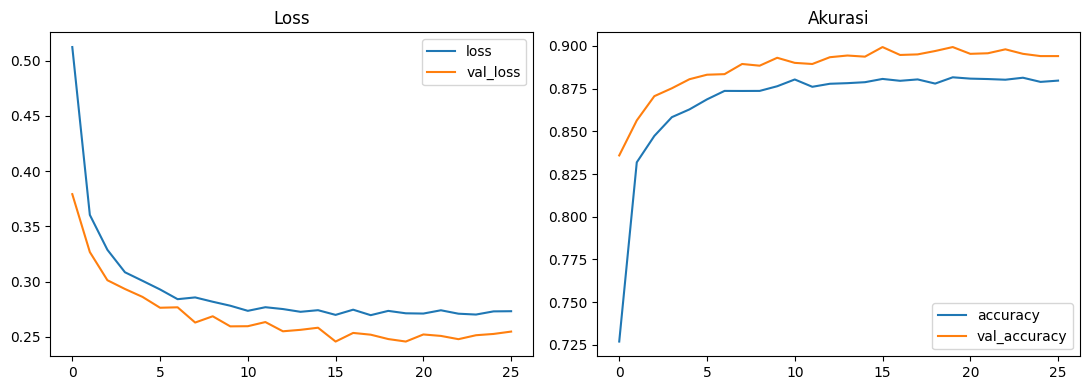

In [6]:
#6Latih Head Klasifikasi
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight = dict(enumerate(cw))

head = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dropout(DROPOUT),
    layers.Dense(1, activation="sigmoid"),
], name="head_metal")
head.compile(optimizer=keras.optimizers.Adam(LR), loss="binary_crossentropy", metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
]
hist = head.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS,
                batch_size=256, class_weight=class_weight, callbacks=callbacks, verbose=2)
pd.DataFrame(hist.history).to_csv(f"{RESULTS_DIR}/history.csv", index=False)

h = pd.DataFrame(hist.history)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
h[["loss", "val_loss"]].plot(ax=ax[0], title="Loss")
h[["accuracy", "val_accuracy"]].plot(ax=ax[1], title="Akurasi")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/training_curves.png", dpi=150); plt.show()

Akurasi: 0.9118 | F1 Metal: 0.8447 | ROC-AUC: 0.9718

              precision    recall  f1-score   support

 Bukan Metal     0.9788    0.9012    0.9384      2258
       Metal     0.7650    0.9429    0.8447       770

    accuracy                         0.9118      3028
   macro avg     0.8719    0.9220    0.8916      3028
weighted avg     0.9245    0.9118    0.9146      3028



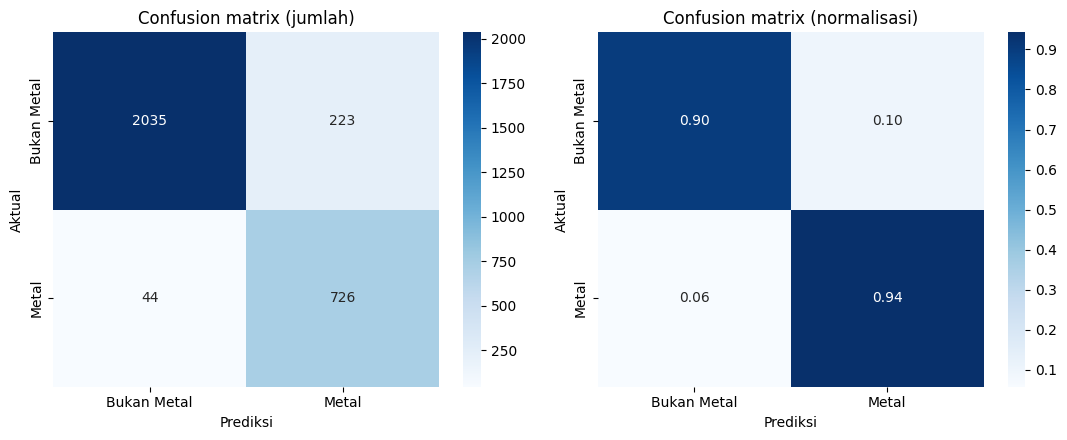

Bukan Metal yang salah ditebak Metal, per kelas asli:
 Glass        111
Plastic       37
Unkown        30
Unlabeled     26
Paper         19


In [7]:
#7Evaluasi pada Data Test
prob = head.predict(X_test, verbose=0).ravel()
y_pred = (prob >= THRESHOLD).astype(int)

acc = float((y_pred == y_test).mean())
f1m = float(f1_score(y_test, y_pred))
auc = float(roc_auc_score(y_test, prob))
print(f"Akurasi: {acc:.4f} | F1 Metal: {f1m:.4f} | ROC-AUC: {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=BIN_NAMES, digits=4))
report = classification_report(y_test, y_pred, target_names=BIN_NAMES, output_dict=True)
pd.DataFrame(report).T.to_csv(f"{RESULTS_DIR}/classification_report.csv")

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=BIN_NAMES, yticklabels=BIN_NAMES, ax=ax[0])
ax[0].set_title("Confusion matrix (jumlah)")
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues",
            xticklabels=BIN_NAMES, yticklabels=BIN_NAMES, ax=ax[1])
ax[1].set_title("Confusion matrix (normalisasi)")
for a in ax: a.set_xlabel("Prediksi"); a.set_ylabel("Aktual")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150); plt.show()

# Kelas asli mana yang salah ditebak sebagai Metal
fp = pd.Series(y6_test[(y_test == 0) & (y_pred == 1)]).map(lambda i: class_names[i]).value_counts()
print("Bukan Metal yang salah ditebak Metal, per kelas asli:\n", fp.to_string() if len(fp) else "tidak ada")

In [8]:
#8Pemilihan Threshold (Precision vs Recall)
for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
    yp = (prob >= t).astype(int)
    print(f"ambang {t}: precision {precision_score(y_test, yp):.3f} | recall {recall_score(y_test, yp):.3f} | F1 {f1_score(y_test, yp):.3f} | salah tuduh {int(((yp == 1) & (y_test == 0)).sum())}")

ambang 0.5: precision 0.765 | recall 0.943 | F1 0.845 | salah tuduh 223
ambang 0.6: precision 0.818 | recall 0.914 | F1 0.863 | salah tuduh 157
ambang 0.7: precision 0.849 | recall 0.871 | F1 0.860 | salah tuduh 119
ambang 0.8: precision 0.895 | recall 0.782 | F1 0.834 | salah tuduh 71
ambang 0.9: precision 0.945 | recall 0.581 | F1 0.719 | salah tuduh 26


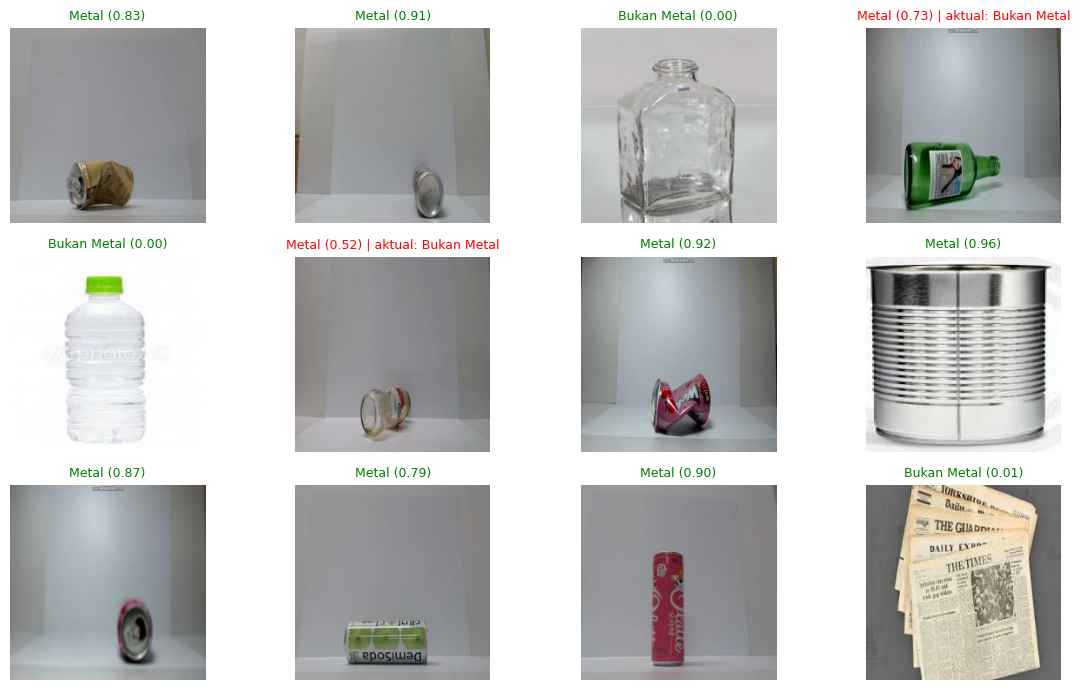

In [9]:
#9Contoh Prediksi
imgs, labels = next(iter(test_ds.unbatch().shuffle(2000, seed=SEED).batch(12)))
pr = head.predict(base.predict(imgs, verbose=0), verbose=0).ravel()
plt.figure(figsize=(12, 7))
for i in range(12):
    plt.subplot(3, 4, i + 1); plt.imshow(imgs[i].numpy().astype("uint8")); plt.axis("off")
    pred = int(pr[i] >= THRESHOLD); actual = int(labels[i].numpy() == METAL_IDX)
    plt.title(f"{BIN_NAMES[pred]} ({pr[i]:.2f})" + ("" if pred == actual else f" | aktual: {BIN_NAMES[actual]}"),
              color="green" if pred == actual else "red", fontsize=9)
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/sample_predictions.png", dpi=150); plt.show()

In [10]:
#10Simpan Model, Ringkasan Hasil, dan Unduh
inputs  = keras.Input(shape=IMG_SIZE + (3,), name="image")   # RGB, piksel 0-255
outputs = head(base(inputs, training=False))
model   = keras.Model(inputs, outputs, name="mobilenetv3_small_metal")
model.save(f"{RESULTS_DIR}/model_metal.keras")

conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
tflite = conv.convert()
open(f"{RESULTS_DIR}/model_metal.tflite", "wb").write(tflite)
json.dump({"classes": BIN_NAMES, "threshold": THRESHOLD, "output": "probabilitas Metal"},
          open(f"{RESULTS_DIR}/model_info.json", "w"), indent=2)
print(f"TFLite: {len(tflite)/1e6:.2f} MB\n")

per_class = pd.DataFrame(report).T.loc[BIN_NAMES, ["precision", "recall", "f1-score", "support"]]
per_class["support"] = per_class["support"].astype(int)
summary = f"""## Hasil Metal vs Bukan Metal (test set)

| Metrik | Nilai |
|---|---|
| Akurasi | {acc:.4f} |
| F1 Metal | {f1m:.4f} |
| ROC-AUC | {auc:.4f} |
| Epoch head | {len(hist.history['loss'])} |

{per_class.round(4).to_markdown()}
"""
open(f"{RESULTS_DIR}/results_summary.md", "w").write(summary)
print(summary)

shutil.make_archive("/content/results_metal", "zip", RESULTS_DIR)
files.download("/content/results_metal.zip")

Saved artifact at '/tmp/tmprj9f0ydi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140338963650640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963644688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963654672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963655440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963654864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963650832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963655248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963650448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963651024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338963655056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140338940708048: Tens

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>